<div style="border: 2px solid #2B5B84; padding: 20px; border-radius: 10px; background-color: #F8F9FA; text-align: center;">
    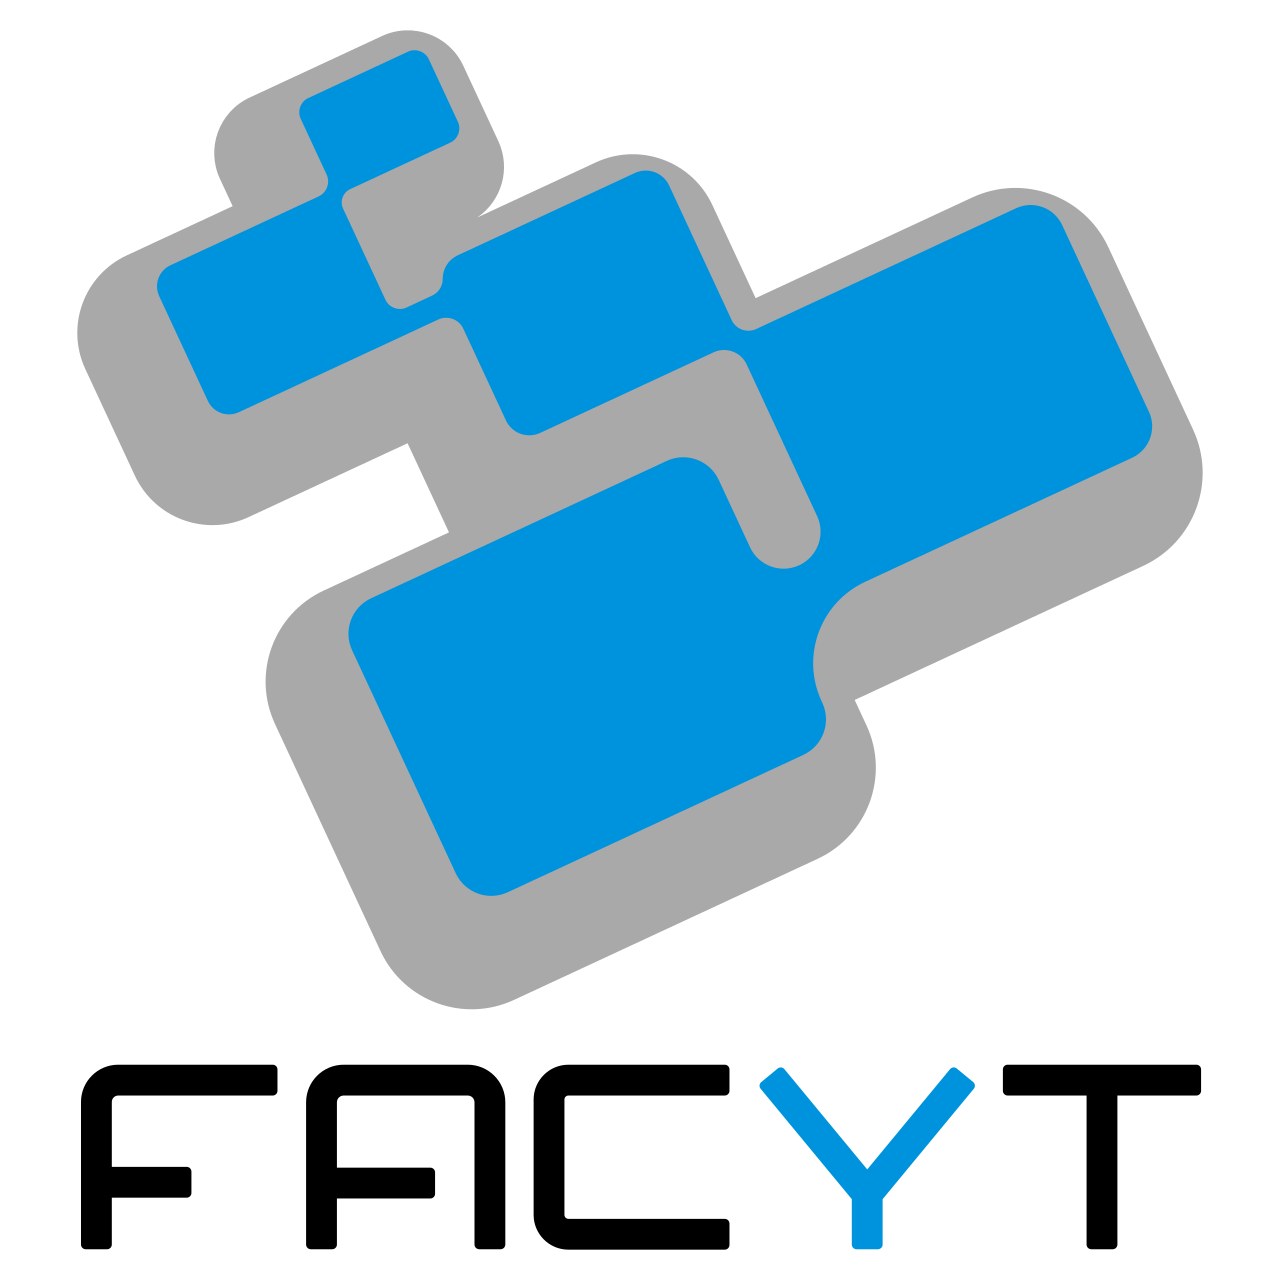
    <h2 style="color: #1B365D; margin-bottom: 2px;">UNIVERSIDAD DE CARABOBO</h2>
    <h3 style="color: #2B5B84; margin-top: 0px;">FACULTAD EXPERIMENTAL DE CIENCIAS Y TECNOLOGÍA (FACYT)</h3>
    <h4 style="color: #4A777A;">DEPARTAMENTO DE COMPUTACIÓN</h4>
    <p><strong>Asignatura:</strong> Aprendizaje Automatizado (Electiva 2026) | <strong>Profesor:</strong> Álvaro Espinoza</p>
    <p><strong>Autores:</strong> Anthony Quero y Luigi Quero</p>
    <hr style="border: 1px solid #2B5B84; margin: 15px 0;">
    <h1 style="color: #D9534F; margin-bottom: 5px;">Asignación 2: Data Preparation y Feature Engineering</h1>
    <h3 style="color: #333333;">Proyecto: Pokémon Battle Winner Predictor</h3>
</div>

# 1. Propósito y contexto del problema

En este notebook convertimos los hallazgos de nuestro EDA (`01_eda_pokemon.ipynb`) en un **pipeline
de preparación de datos reproducible y seguro frente a data leakage**. No entrenamos, comparamos ni
optimizamos ningún modelo: eso corresponde al siguiente notebook del proyecto.

| Elemento | Definición |
|---|---|
| **Unidad de observación** | Un combate histórico entre `First_pokemon` (posición 1) y `Second_pokemon` (posición 2). |
| **Variable objetivo** | `Target_First_Wins` = 1 si `Winner == First_pokemon`, 0 en caso contrario (clasificación binaria). |
| **Qué representa una predicción** | La probabilidad de que el Pokémon en posición 1 gane un combate **no observado antes** entre dos Pokémon conocidos (*Escenario A* del EDA). |
| **Información disponible al predecir** | Todo lo que se conoce *antes* del combate: stats base, tipos, indicador Legendary y nombre de ambos Pokémon (el nombre se usa para detectar formas especiales), y la posición que ocupa cada uno. |
| **Columnas excluidas** | `Winner` (*es* el resultado → leakage directo); `First_pokemon`, `Second_pokemon` como predictores (IDs → memorización; solo los usamos para agrupar el split); `Name_*` crudos (texto libre, solo nos sirve para derivar la forma especial); `Generation_*` (ver §8). No usamos `tests.csv` (archivo de Kaggle sin etiqueta), igual que en el EDA. |

> **Importante.** Realizamos el EDA sobre los 50,000 combates **antes** de cualquier split. Por lo
> tanto, reconocemos que el conjunto de test ya influyó indirectamente en algunas de nuestras
> decisiones (por ejemplo, el baseline de velocidad de 94.05% y la elección de las cinco master
> features). A partir de este notebook **no tomamos ninguna decisión con el test**: solo lo usamos
> para comprobar su tamaño, su proporción de clases y que no comparte observaciones con train.

# 2. Hallazgos relevantes del EDA

Recogemos solo los hallazgos de nuestro EDA necesarios para entender las decisiones de preparación
(los números de sección se refieren a `01_eda_pokemon.ipynb`):

- **Valores ausentes:** `Type 2` falta en ~48% de los combatientes → especies monotipo; el nulo es
  informativo (§3.1). Una especie (`#63`) no tiene nombre; sus stats coinciden exactamente con los de
  **Primeape** (§3.2).
- **Duplicados:** 1,952 combates duplicados exactos (3.9%). Su origen (ejecuciones repetidas del
  simulador) es una **hipótesis**; en el EDA decidimos eliminarlos antes del split (§3.3, §11.5).
- **Target:** First gana el 47.20% y Second el 52.80% → baseline de clase mayoritaria de 52.80% (§4).
- **Velocidad:** el más rápido gana la mayoría de los combates (First gana el 92.39% cuando es más
  rápido y el 4.60% cuando es más lento). En los 1,328 empates exactos de velocidad ganó siempre
  Second (§5.1). 1,822 parejas pelearon en ambos órdenes y el 94.0% mantuvo el mismo ganador (§5.2).
- **Diferenciales:** entre las features diferenciales numéricas exploradas, `Speed_diff` muestra la
  asociación lineal univariada más fuerte con el target ($r = +0.678$), seguida de `Total_diff`
  ($r = +0.470$). `Total_diff` y `Attack_diff` están correlacionadas ($r \approx 0.74$) (§6).
- **Tipos:** con ventaja de tipo, First gana el 52.77%; con desventaja, el 42.05% (§7). En la
  revisión de la Asignación 1 nuestra tabla de tipos quedó señalada como una aproximación pendiente
  de validar.
- **Formas especiales:** Mega/Primal/Legendario/Formas alternativas ganan el 73.6–83.3% contra
  Pokémon estándar. Si esto se debe a la categoría o a sus stats más altos es una **hipótesis**
  (confounding) (§8, §11.2).
- **Identidad:** la identidad de la especie aporta señal, pero debe entrar a través de stats/formas,
  nunca mediante IDs crudos (§9).
- **Baselines:** clase mayoritaria 52.80% y Strong Speed-Based Baseline 94.05% (§11.1).

# 3. Tabla EDA → decisiones de preparación

Cada decisión que tomamos en este notebook se apoya en un hallazgo concreto de nuestro EDA:

| Hallazgo del EDA | Evidencia | Decisión | Justificación |
|---|---|---|---|
| `Winner` contiene el resultado | Definición del target (EDA §1, §11.5) | Construir `Target_First_Wins` y eliminar `Winner` | Se desconoce antes del combate → leakage directo |
| IDs de Pokémon con alta cardinalidad (784 especies) | `nunique` (EDA §2), win rate por especie (EDA §9) | Excluir los IDs del modelo; conservarlos solo para agrupar el split | Evitar que el modelo memorice especies en lugar de aprender mecánicas |
| 1,952 duplicados exactos | `duplicated().sum()` (EDA §3.3) | `drop_duplicates()` **antes** del split | Copias idénticas podrían caer en train y test e inflar las métricas |
| El mismo enfrentamiento aparece en ambos órdenes (1,822 parejas, 94% mismo ganador) | Análisis de orientación (EDA §5.2) | Agrupar el split por **pareja no ordenada** | El Escenario A exige que el enfrentamiento de test sea nuevo; deduplicar no separa A-vs-B de B-vs-A |
| Target casi balanceado (47.2 / 52.8) | `value_counts` (EDA §4) | Estratificar el split por el target | Misma proporción de clases en train y test; no hace falta re-muestrear |
| `Type 2` nulo ≈ 48% = monotipo | % de nulos (EDA §3.1) | Imputar la categoría constante `"None"` (no la moda) | El nulo significa "sin segundo tipo"; la moda inventaría un tipo |
| La especie `#63` no tiene nombre | Sus stats son iguales a los de Primeape (EDA §3.2) | Imputación determinista `Name = "Primeape"` al cargar | Es un hecho del dominio, no una estadística aprendida → sin leakage |
| Speed tiene la asociación univariada más fuerte | $r = +0.678$ (EDA §6) | Conservar `Speed_diff` | Iniciativa de turno, conocida antes del combate |
| Brecha de poder total | $r = +0.470$ (EDA §6) | Conservar `Stat_Total_Diff`; no añadir `Total_first/second` | Los totales individuales son una combinación lineal exacta de los seis stats |
| Interacción ataque vs defensa | EDA §6, §10 | Conservar `Atk_Def_Penetration_Diff` | Daño físico relativo |
| Ventaja de tipo (+10.7 pp) | Win rate según ventaja (EDA §7.2) | Conservar `Type_Advantage_Ratio` **tras validar la tabla de tipos** (§5.4) | Conocimiento del dominio; la tabla estaba señalada como aproximada |
| Las formas especiales dominan (73.6–83.3%) | Heatmap de formas (EDA §8.2) | Conservar `Special_Form_Advantage` $\in\{-1,0,1\}$ como ordinal | Resume el nivel evolutivo; el confounding con los stats sigue siendo una hipótesis |
| Los tipos son categorías nominales; algunos cruces destacan | Tabla de roles (EDA §2), heatmap de tipos (EDA §7.3) | One-hot de `Type 1/2` de ambos combatientes, agrupando las categorías raras (umbral elegido con las frecuencias de train, §9) | Los tipos no tienen orden; una categoría casi vacía produce columnas inestables |
| No hay stats inválidos, pero sí valores extremos reales (p. ej. Shuckle, especie con 0% de victorias) | Validación de dominio (EDA §3.3), especies débiles (EDA §9.2), `describe` de la penetración con min/max ≈ ±35 frente a un IQR de ±0.76 (EDA §10.1) | Conservarlos, sin recorte | Son especies reales, no errores; eliminarlas quitaría información válida |
| Escalas muy distintas entre las features | `describe` (EDA §10.1): desviación ≈ 170 en `Stat_Total_Diff`, ≈ 41 en `Speed_diff`, ≈ 0.8 en `Type_Advantage_Ratio` | `StandardScaler`, ajustado solo con train | Los modelos candidatos de nuestro roadmap (Logistic Regression, KNN, MLP) son sensibles a la escala; así lo previmos en el protocolo del EDA §11.5 |
| Generation sin impacto claro | EDA §11.3 (P7) | Excluir `Generation_*` tras confirmarlo en train (§8) | Atributo de catálogo, no una mecánica de combate |
| El win rate por especie tiene señal | EDA §9 | **No** construir aquí un win rate por especie / target encoding | Se calcula a partir del target → leakage salvo que se calcule dentro de cada fold de CV |

# 4. Imports, constantes y rutas

Diseñamos el notebook para que se ejecute desde un kernel reiniciado. Usamos rutas relativas para que
funcione tanto desde `notebooks/` como desde la raíz del repositorio. **Importamos** las cinco master
features desde `scripts/features.py`, el módulo reutilizable de feature engineering que construimos
en la Asignación 1, en lugar de reimplementarlas aquí. No usamos ningún filtro global de warnings.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# --- Rutas (funciona desde notebooks/ o desde la raíz del repositorio) ---
PROJECT_ROOT = Path("..").resolve() if Path("../data/combats.csv").exists() else Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
POKEMON_PATH = DATA_DIR / "pokemon.csv"
COMBATS_PATH = DATA_DIR / "combats.csv"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))
from features import TYPE_CHART, add_master_features  # módulo reutilizable de la Asignación 1

# --- Constantes ---
RANDOM_STATE = 42
N_SPLITS = 5                      # se reserva 1 de 5 folds estratificados y agrupados -> ~20% test
TARGET = "Target_First_Wins"
STAT_COLS = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
EXPECTED_POKEMON_COLS = ["#", "Name", "Type 1", "Type 2", *STAT_COLS, "Generation", "Legendary"]
EXPECTED_COMBATS_COLS = ["First_pokemon", "Second_pokemon", "Winner"]
VALID_TYPES = {"Normal", "Fire", "Water", "Electric", "Grass", "Ice", "Fighting", "Poison", "Ground",
               "Flying", "Psychic", "Bug", "Rock", "Ghost", "Dragon", "Dark", "Steel", "Fairy"}
MASTER_FEATURES = ["Speed_diff", "Stat_Total_Diff", "Atk_Def_Penetration_Diff",
                   "Special_Form_Advantage", "Type_Advantage_Ratio"]

pd.set_option("display.max_columns", None)
print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__}")

Raíz del proyecto: C:\Users\Admin\Documents\ML\REPO\pokemon_battle_winner_predictor
pandas 3.0.5 | numpy 2.5.2 | scikit-learn 1.9.0


**Interpretación.** Las rutas se resuelven de forma relativa, dejamos registradas las versiones de
las librerías para la reproducibilidad y la semilla `RANDOM_STATE = 42` fija el split. Como las
funciones de features provienen de un único módulo, este notebook y nuestro notebook de modelado
usarán exactamente el mismo cálculo.

# 5. Carga y validación de los datos

Partimos de los archivos **crudos** (`pokemon.csv`, `combats.csv`) y no de
`pokemon_combats_unified.csv`, porque la tabla unificada ya contiene columnas derivadas y la
imputación de Primeape, lo que ocultaría las comprobaciones siguientes.

Para cada comprobación usamos una pequeña función `check()` que lanza un `ValueError` con un mensaje
explícito; no silenciamos nada. Los resultados se acumulan en un registro de validaciones.

In [2]:
validation_log = []

def check(condition, name, detail):
    # Lanza un error explícito y legible si se viola un invariante; si no, lo registra.
    if not bool(condition):
        raise ValueError(f"Validación fallida - {name}: {detail}")
    validation_log.append({"comprobación": name, "detalle": detail, "estado": "OK"})

pokemon = pd.read_csv(POKEMON_PATH)
combats = pd.read_csv(COMBATS_PATH)
print(f"pokemon.csv: {pokemon.shape[0]:,} filas x {pokemon.shape[1]} columnas")
print(f"combats.csv: {combats.shape[0]:,} filas x {combats.shape[1]} columnas")

pokemon.csv: 800 filas x 12 columnas
combats.csv: 50,000 filas x 3 columnas


## 5.1 Catálogo de Pokémon: esquema, identificadores, rangos y categorías

In [3]:
missing_cols = sorted(set(EXPECTED_POKEMON_COLS) - set(pokemon.columns))
check(not missing_cols, "columnas requeridas en pokemon", f"faltantes: {missing_cols or 'ninguna'}")
check(pokemon["#"].is_unique, "id de pokemon único", f"{pokemon['#'].nunique()} ids únicos")
check(pokemon["#"].between(1, 800).all(), "rango de id de pokemon", "todos los ids en [1, 800]")

for stat in STAT_COLS:
    col = pokemon[stat]
    check(pd.api.types.is_integer_dtype(col) and col.notna().all(), f"{stat} entero y sin nulos", "ok")
    check(col.between(1, 255).all(), f"rango de {stat}", f"min={col.min()}, max={col.max()} dentro de [1, 255]")

check(pokemon["Type 1"].notna().all(), "Type 1 sin nulos", "toda especie tiene un tipo primario")
bad_t1 = sorted(set(pokemon["Type 1"]) - VALID_TYPES)
bad_t2 = sorted(set(pokemon["Type 2"].dropna()) - VALID_TYPES)
check(not bad_t1 and not bad_t2, "categorías de tipo válidas", f"Type 1 inválidos: {bad_t1}, Type 2 inválidos: {bad_t2}")
check((pokemon["Type 1"] != pokemon["Type 2"]).all(), "Type 1 != Type 2", "ninguna especie repite su tipo")
check(pokemon["Generation"].between(1, 6).all(), "rango de Generation", "todas en [1, 6]")
check(pd.api.types.is_bool_dtype(pokemon["Legendary"]), "Legendary booleano", str(pokemon["Legendary"].dtype))

print(f"Type 2 ausente: {pokemon['Type 2'].isna().sum()} especies "
      f"({pokemon['Type 2'].isna().mean() * 100:.1f}%) -> monotipo, se trata en el pipeline (sección 9)")

Type 2 ausente: 386 especies (48.2%) -> monotipo, se trata en el pipeline (sección 9)


## 5.2 Nombre ausente de la especie `#63`

En el EDA identificamos que el único `Name` ausente pertenece a la especie `#63`, cuyos stats
coinciden exactamente con los de Primeape. Lo verificamos antes de imputar. La imputación es un hecho
determinista del dominio, no una estadística aprendida de los datos, así que podemos hacerla sin
riesgo antes del split.

In [4]:
PRIMEAPE_STATS = {"HP": 65, "Attack": 105, "Defense": 60, "Sp. Atk": 60, "Sp. Def": 70, "Speed": 95}

unnamed = pokemon.loc[pokemon["Name"].isna()]
display(unnamed)
check(unnamed["#"].tolist() == [63], "solo #63 sin nombre", f"ids sin nombre: {unnamed['#'].tolist()}")
observed = unnamed.iloc[0][STAT_COLS].astype(int).to_dict()
check(observed == PRIMEAPE_STATS, "#63 coincide con Primeape", f"stats observados: {observed}")

pokemon.loc[pokemon["#"] == 63, "Name"] = "Primeape"
check(pokemon["Name"].notna().all(), "sin nombres ausentes", "tras la imputación")

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
62,63,NaN,Fighting,NaN,65,105,60,60,70,95,1,False


## 5.3 Combates: esquema, integridad referencial, presencia del target y duplicados

In [5]:
missing_cols = sorted(set(EXPECTED_COMBATS_COLS) - set(combats.columns))
check(not missing_cols, "columnas requeridas en combats", f"faltantes: {missing_cols or 'ninguna'}")
check(combats.notna().all().all(), "combats sin nulos", "sin ids ni ganadores ausentes")

valid_ids = set(pokemon["#"])
for col in EXPECTED_COMBATS_COLS:
    unknown = set(combats[col]) - valid_ids
    check(not unknown, f"ids de {col} existen", f"{len(unknown)} ids desconocidos")

check((combats["First_pokemon"] != combats["Second_pokemon"]).all(), "sin combates contra sí mismo", "First != Second")
winner_ok = combats["Winner"].eq(combats["First_pokemon"]) | combats["Winner"].eq(combats["Second_pokemon"])
check(winner_ok.all(), "target derivable", "Winner es siempre uno de los dos combatientes")

n_raw = len(combats)
n_dup = int(combats.duplicated().sum())
combats = combats.drop_duplicates().reset_index(drop=True)
check(len(combats) == n_raw - n_dup, "duplicados eliminados", f"{n_dup:,} duplicados exactos eliminados")
print(f"Combates: {n_raw:,} crudos -> {len(combats):,} tras eliminar {n_dup:,} duplicados exactos "
      f"({n_dup / n_raw * 100:.1f}%)")

Combates: 50,000 crudos -> 48,048 tras eliminar 1,952 duplicados exactos (3.9%)


## 5.4 Validación de la tabla de efectividad de tipos

En la revisión de nuestra Asignación 1, el profesor nos indicó que debíamos validar la tabla
`TYPE_CHART`, que construimos a mano, antes de usar `Type_Advantage_Ratio` como feature. Para ello
transcribimos por separado la tabla oficial de la Generación VI (para cada tipo atacante: tipos a los
que hace ×2, ×0.5 y ×0) y la comparamos entrada por entrada con la tabla de `scripts/features.py`.
Todo par no listado es neutro (×1) por definición.

In [6]:
# Tabla oficial de la Generación VI: tipo atacante -> (súper eficaz, poco eficaz, sin efecto)
GEN6_REFERENCE = {
    "Normal":   ([], ["Rock", "Steel"], ["Ghost"]),
    "Fire":     (["Grass", "Ice", "Bug", "Steel"], ["Fire", "Water", "Rock", "Dragon"], []),
    "Water":    (["Fire", "Ground", "Rock"], ["Water", "Grass", "Dragon"], []),
    "Electric": (["Water", "Flying"], ["Electric", "Grass", "Dragon"], ["Ground"]),
    "Grass":    (["Water", "Ground", "Rock"], ["Fire", "Grass", "Poison", "Flying", "Bug", "Dragon", "Steel"], []),
    "Ice":      (["Grass", "Ground", "Flying", "Dragon"], ["Fire", "Water", "Ice", "Steel"], []),
    "Fighting": (["Normal", "Ice", "Rock", "Dark", "Steel"], ["Poison", "Flying", "Psychic", "Bug", "Fairy"], ["Ghost"]),
    "Poison":   (["Grass", "Fairy"], ["Poison", "Ground", "Rock", "Ghost"], ["Steel"]),
    "Ground":   (["Fire", "Electric", "Poison", "Rock", "Steel"], ["Grass", "Bug"], ["Flying"]),
    "Flying":   (["Grass", "Fighting", "Bug"], ["Electric", "Rock", "Steel"], []),
    "Psychic":  (["Fighting", "Poison"], ["Psychic", "Steel"], ["Dark"]),
    "Bug":      (["Grass", "Psychic", "Dark"], ["Fire", "Fighting", "Poison", "Flying", "Ghost", "Steel", "Fairy"], []),
    "Rock":     (["Fire", "Ice", "Flying", "Bug"], ["Fighting", "Ground", "Steel"], []),
    "Ghost":    (["Psychic", "Ghost"], ["Dark"], ["Normal"]),
    "Dragon":   (["Dragon"], ["Steel"], ["Fairy"]),
    "Dark":     (["Psychic", "Ghost"], ["Fighting", "Dark", "Fairy"], []),
    "Steel":    (["Ice", "Rock", "Fairy"], ["Fire", "Water", "Electric", "Steel"], []),
    "Fairy":    (["Fighting", "Dragon", "Dark"], ["Fire", "Poison", "Steel"], []),
}
reference_chart = {}
for attacker, (double, half, zero) in GEN6_REFERENCE.items():
    reference_chart.update({(attacker, d): 2.0 for d in double})
    reference_chart.update({(attacker, d): 0.5 for d in half})
    reference_chart.update({(attacker, d): 0.0 for d in zero})

chart_types = {t for pair in TYPE_CHART for t in pair}
check(chart_types <= VALID_TYPES, "la tabla usa tipos válidos", f"{len(chart_types)} tipos referenciados")
check(set(TYPE_CHART.values()) <= {0.0, 0.5, 2.0}, "multiplicadores de la tabla", f"valores: {sorted(set(TYPE_CHART.values()))}")

missing_pairs = sorted(set(reference_chart) - set(TYPE_CHART))
extra_pairs = sorted(set(TYPE_CHART) - set(reference_chart))
wrong_values = sorted(k for k in set(reference_chart) & set(TYPE_CHART) if reference_chart[k] != TYPE_CHART[k])
print(f"Cruces no neutros -> tabla del proyecto: {len(TYPE_CHART)}, referencia Gen VI: {len(reference_chart)}")
print(f"Faltantes: {missing_pairs} | Sobrantes: {extra_pairs} | Valor distinto: {wrong_values}")
check(not missing_pairs and not extra_pairs and not wrong_values, "la tabla coincide con la referencia Gen VI",
      "las 324 combinaciones atacante/defensor coinciden")

Cruces no neutros -> tabla del proyecto: 120, referencia Gen VI: 120
Faltantes: [] | Sobrantes: [] | Valor distinto: []


## 5.5 Merge, construcción del target y comprobaciones post-merge

Unimos cada combate dos veces con el catálogo (sufijos `_first` / `_second`, la misma nomenclatura
de nuestro EDA). `validate="many_to_one"` hace que pandas falle si un id de Pokémon estuviera
duplicado en el catálogo. Creamos el target y eliminamos `Winner` de inmediato.

In [7]:
battles = (
    combats
    .merge(pokemon.add_suffix("_first"), left_on="First_pokemon", right_on="#_first",
           how="left", validate="many_to_one")
    .merge(pokemon.add_suffix("_second"), left_on="Second_pokemon", right_on="#_second",
           how="left", validate="many_to_one")
    .drop(columns=["#_first", "#_second"])
)
check(len(battles) == len(combats), "el merge conserva las filas", f"{len(battles):,} filas")
merged_cols = [f"{c}_{side}" for side in ("first", "second") for c in ["Name", "Type 1", *STAT_COLS]]
check(battles[merged_cols].notna().all().all(), "el merge no introduce nulos", "stats, nombres y Type 1")

battles[TARGET] = (battles["Winner"] == battles["First_pokemon"]).astype(int)
check(set(battles[TARGET].unique()) <= {0, 1}, "dominio del target", "valores en {0, 1}")
battles = battles.drop(columns=["Winner"])          # columna de resultado: nunca es predictora
check("Winner" not in battles.columns, "Winner eliminada", "columna con leakage eliminada")

numeric = battles.select_dtypes("number")
check(np.isfinite(numeric.to_numpy(dtype=float)).all(), "sin valores infinitos", f"{numeric.shape[1]} columnas numéricas")

print(f"Tabla analítica: {battles.shape[0]:,} combates x {battles.shape[1]} columnas")
battles.head(3)

Tabla analítica: 48,048 combates x 25 columnas


,First_pokemon,Second_pokemon,Name_first,Type 1_first,Type 2_first,HP_first,Attack_first,Defense_first,Sp. Atk_first,Sp. Def_first,Speed_first,Generation_first,Legendary_first,Name_second,Type 1_second,Type 2_second,HP_second,Attack_second,Defense_second,Sp. Atk_second,Sp. Def_second,Speed_second,Generation_second,Legendary_second,Target_First_Wins
0,266,298,Larvitar,Rock,Ground,50,64,50,45,50,41,2,False,Nuzleaf,Grass,Dark,70,70,40,60,40,60,3,False,0
1,702,701,Virizion,Grass,Fighting,91,90,72,90,129,108,5,True,Terrakion,Rock,Fighting,91,129,90,72,90,108,5,True,0
2,191,668,Togetic,Fairy,Flying,55,40,85,80,105,40,2,False,Beheeyem,Psychic,NaN,75,75,75,125,95,40,5,False,0


In [8]:
pd.DataFrame(validation_log)

,comprobación,detalle,estado
0,columnas requeridas en pokemon,faltantes: ninguna,OK
1,id de pokemon único,800 ids únicos,OK
2,rango de id de pokemon,"todos los ids en [1, 800]",OK
3,HP entero y sin nulos,ok,OK
4,rango de HP,"min=1, max=255 dentro de [1, 255]",OK
5,Attack entero y sin nulos,ok,OK
6,rango de Attack,"min=5, max=190 dentro de [1, 255]",OK
7,Defense entero y sin nulos,ok,OK
8,rango de Defense,"min=5, max=230 dentro de [1, 255]",OK
9,Sp. Atk entero y sin nulos,ok,OK


**Interpretación.** Todas las comprobaciones pasan. Los datos crudos solo necesitaron dos acciones de
limpieza, ambas deterministas y justificadas por nuestro EDA:

- imputar el nombre de la especie `#63`;
- eliminar los 1,952 duplicados exactos, con lo que nos quedan 48,048 combates.

Nuestra tabla de tipos de `scripts/features.py` coincide con la tabla oficial de la Generación VI en
cada una de sus entradas, así que `Type_Advantage_Ratio` ya no está limitada por la tabla. Sigue siendo
una simplificación del combate real, porque toma el mejor de los dos tipos del atacante e ignora los
movimientos. La tabla resultante tiene 25 columnas, incluido el target, y `Winner` ya fue eliminada.

# 6. Separación train/test

Hacemos el split **antes** de cualquier transformación que aprenda de los datos. Nuestra elección
sigue la definición de *combate no visto* que adoptamos en el EDA (**Escenario A**: un enfrentamiento
nuevo entre Pokémon que ya se observaron en otros combates).

| Tipo de split | ¿Aplica? | Razón |
|---|---|---|
| Aleatorio | No | No controlaría la proporción de clases ni mantendría un enfrentamiento en un solo lado |
| Estratificado | **Sí** | El target está en 47.2 / 52.8 → mantener la misma proporción en ambos conjuntos |
| Agrupado por entidad | **Sí** | Tras deduplicar, 1,822 parejas no ordenadas siguen apareciendo en ambos órdenes (A vs B y B vs A). Un split aleatorio podría dejar una orientación en train y la otra en test, así que el enfrentamiento "nuevo" de test ya sería conocido |
| Temporal | No | Los combates no tienen fecha ni orden |

**Refinamiento respecto a nuestro roadmap del EDA.** En el EDA (§11.6) propusimos eliminar los
duplicados y luego hacer un split estratificado 80/20. Mantenemos ambas cosas, pero añadimos la
agrupación por pareja. La deduplicación elimina las copias exactas, pero no el mismo enfrentamiento
con el orden invertido, y nuestra propia definición del Escenario A exige que el enfrentamiento de
test sea nuevo.

Por eso usamos `StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)` con la **pareja no
ordenada** como grupo, y reservamos el primer fold (~20%) como test. Reutilizaremos el mismo
`groups_train` para la validación cruzada en nuestro notebook de modelado.

In [9]:
battles["pair_id"] = [f"{min(a, b)}_{max(a, b)}"
                      for a, b in zip(battles["First_pokemon"], battles["Second_pokemon"])]
pair_sizes = battles["pair_id"].value_counts()
print(f"Parejas no ordenadas: {len(pair_sizes):,} | parejas en ambos órdenes: {(pair_sizes == 2).sum():,} "
      f"({pair_sizes[pair_sizes == 2].sum():,} combates)")

X = battles.drop(columns=[TARGET])
y = battles[TARGET]
groups = battles["pair_id"]

splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()

Parejas no ordenadas: 46,226 | parejas en ambos órdenes: 1,822 (3,644 combates)


In [10]:
train_species = set(X_train["First_pokemon"]) | set(X_train["Second_pokemon"])
test_species = set(X_test["First_pokemon"]) | set(X_test["Second_pokemon"])
shared_rows = set(X_train.index) & set(X_test.index)
shared_pairs = set(X_train["pair_id"]) & set(X_test["pair_id"])

check(not shared_rows, "sin observaciones compartidas", "los índices de train y test son disjuntos")
check(not shared_pairs, "sin enfrentamientos compartidos", "ninguna pareja no ordenada en ambos conjuntos")

split_summary = pd.DataFrame({
    "combates": [len(X_train), len(X_test)],
    "proporción_%": [len(X_train) / len(X) * 100, len(X_test) / len(X) * 100],
    "win_rate_first_%": [y_train.mean() * 100, y_test.mean() * 100],
}, index=["train", "test"]).round(2)
display(split_summary)
print(f"Filas compartidas: {len(shared_rows)} | parejas compartidas: {len(shared_pairs)} | "
      f"especies de test nunca vistas en train: {len(test_species - train_species)}")

,combates,proporción_%,win_rate_first_%
train,38439,80.0,47.19
test,9609,20.0,47.20


Filas compartidas: 0 | parejas compartidas: 0 | especies de test nunca vistas en train: 0


**Interpretación.** Train y test mantienen la proporción 80/20 y el mismo balance de clases (~47.2%
de victorias de First). No comparten filas ni enfrentamientos, y todos los Pokémon de test también
pelean en train: es exactamente el **Escenario A**. El Escenario B (Pokémon nunca vistos en
entrenamiento) requeriría agrupar por especie; lo dejamos como limitación.

A partir de aquí apartamos `X_test` y `y_test`: nada de lo que sigue lo ajustamos, describimos ni
decidimos con ellos.

# 7. Feature engineering

Conservamos las **cinco master features** que diseñamos en el EDA (§10) e implementamos en
`scripts/features.py`. Todas se calculan fila a fila, así que no aprenden nada de los datos. Dentro
del pipeline las aplicamos mediante `FunctionTransformer(add_master_features)` (sección 10), de modo
que no dependen de celdas manuales.

Usando la clasificación de familias de la asignación, nuestras cinco features pertenecen a **tres
familias distintas**:

- **Sumas, diferencias, razones o tasas:** `Speed_diff`, `Stat_Total_Diff` y
  `Atk_Def_Penetration_Diff`.
- **Conocimiento específico del dominio:** `Type_Advantage_Ratio` (tabla de efectividad de tipos, con
  una transformación logarítmica) y `Special_Form_Advantage`.
- **Características sencillas de texto:** `Special_Form_Advantage`, que detecta patrones en el nombre
  (`"Mega "`, `"Primal "`, `"Forme"`…).

| Feature | Familia | Columnas usadas | Qué representa / por qué podría ayudar | ¿Disponible al predecir? | Riesgo de leakage / redundancia |
|---|---|---|---|---|---|
| `Speed_diff` | Sumas, diferencias, razones |`Speed_first`, `Speed_second` | Iniciativa de turno; la asociación lineal univariada más fuerte en el EDA ($r = +0.678$) | Sí (stats base) | Sin leakage. Es combinación lineal exacta de los dos Speed crudos (ver §8) |
| `Stat_Total_Diff` | Sumas, diferencias, razones |Los seis stats de cada combatiente | Brecha de poder global ($r = +0.470$) | Sí | Sin leakage. Combinación lineal exacta de los 12 stats crudos (ver §8); correlacionada con `Attack_diff` ($r \approx 0.74$) |
| `Atk_Def_Penetration_Diff` | Sumas, diferencias, razones |`Attack_*`, `Defense_*` | $\frac{Atk_1}{Def_2}-\frac{Atk_2}{Def_1}$: daño físico relativo | Sí | Sin leakage; no lineal respecto a los stats crudos; colas largas (valores reales: los conservamos y los escalamos) |
| `Type_Advantage_Ratio` | Conocimiento del dominio (con transformación logarítmica) |`Type 1/2` de ambos + `TYPE_CHART` | $\log_2\frac{Eff_{1\to2}+0.1}{Eff_{2\to1}+0.1}$: ventaja elemental | Sí (los tipos se conocen) | Tabla externa fija (validada en §5.4), no aprendida de los datos |
| `Special_Form_Advantage` | Conocimiento del dominio y texto sencillo |`Name_*`, `Legendary_*` | $is\_special_1 - is\_special_2$ (Mega, Primal, forma alternativa, Legendario) | Sí (el nombre se conoce) | Confundida con los stats (hipótesis); la taxonomía basada en el nombre es una heurística |

**Candidatas que descartamos:** un win rate histórico por especie (target encoding) usa el target y
provocaría leakage salvo que se calcule dentro de cada fold; usar los IDs crudos como categorías
permitiría a los modelos memorizar especies. Por eso dejamos ambas fuera de este notebook.

A continuación solo **inspeccionamos** las features en train, para confirmar que se comportan como
se esperaba.

In [11]:
train_features = add_master_features(X_train)          # devuelve una copia; X_train no se modifica
display(train_features[MASTER_FEATURES].describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
Speed_diff,38439.0,-0.197,41.410,-170.000,-30.00,0.000,29.000,165.000
Stat_Total_Diff,38439.0,-0.096,170.279,-585.000,-117.00,0.000,120.000,590.000
Atk_Def_Penetration_Diff,38439.0,0.004,1.817,-32.933,-0.75,0.006,0.757,36.957
Special_Form_Advantage,38439.0,-0.001,0.510,-1.000,0.00,0.000,0.000,1.000
Type_Advantage_Ratio,38439.0,-0.003,0.786,-4.392,0.00,0.000,0.000,4.392


In [12]:
def first_win_rate(values):
    # Win rate de First (solo train) para cada valor / signo de una feature.
    return (y_train.groupby(values).agg(combates="size", win_rate_first="mean")
            .assign(win_rate_first=lambda t: (t["win_rate_first"] * 100).round(2)))

sign = lambda s: np.sign(s).map({-1: "First en desventaja", 0: "Igualados", 1: "First en ventaja"})
display(first_win_rate(sign(train_features["Speed_diff"]).rename("signo de Speed_diff")))
display(first_win_rate(sign(train_features["Type_Advantage_Ratio"]).rename("signo de Type_Advantage_Ratio")))
display(first_win_rate(train_features["Special_Form_Advantage"].rename("Special_Form_Advantage")))

tails = train_features["Atk_Def_Penetration_Diff"].quantile([0.0, 0.01, 0.25, 0.5, 0.75, 0.99, 1.0])
print("Cuantiles de Atk_Def_Penetration_Diff (train):")
print(tails.round(3).to_string())

,combates,win_rate_first
signo de Speed_diff,,
First en desventaja,18735,4.63
First en ventaja,18674,92.49
Igualados,1030,0.00


,combates,win_rate_first
signo de Type_Advantage_Ratio,,
First en desventaja,8657,41.95
First en ventaja,8503,52.91
Igualados,21279,47.03


,combates,win_rate_first
Special_Form_Advantage,,
-1,5022,18.66
0,28426,47.14
1,4991,76.16


Cuantiles de Atk_Def_Penetration_Diff (train):
0.00   -32.933
0.01    -4.000
0.25    -0.750
0.50     0.006
0.75     0.757
0.99     4.000
1.00    36.957


**Interpretación (solo train).** Las features muestran el mismo patrón que observamos en el EDA, lo
que sugiere que nuestros hallazgos no dependían de las filas que ahora reservamos como test.

- **`Speed_diff`:** su signo separa las clases con mucha nitidez. Cuando las velocidades están
  igualadas, First no gana nunca, lo que es coherente con la regla de empate.
- **`Type_Advantage_Ratio`:** la ventaja de tipo mueve el win rate de First unos cinco o seis puntos
  en cada dirección (≈53% con ventaja frente a ≈42% con desventaja), como en el EDA.
- **`Special_Form_Advantage`:** hay una gran diferencia entre −1 y +1. Sigue siendo una hipótesis si
  se debe a la categoría o a los stats.
- **`Atk_Def_Penetration_Diff`:** está concentrada alrededor de 0, con algunos valores extremos
  producidos por especies reales con Defense muy baja o muy alta. Los conservamos, y el escalado se
  encarga de la magnitud.

# 8. Definición de grupos de columnas

Asignamos a cada columna un rol explícito. Primero confirmamos **solo con train** la conclusión de
nuestro EDA de que `Generation` no tiene una relación clara con el resultado, lo que respalda su
exclusión.

In [13]:
generation_gap = (X_train["Generation_first"] - X_train["Generation_second"]).rename("Generation_first - Generation_second")
display(first_win_rate(generation_gap).T)
print(f"Correlación de la diferencia de generación con el target (train): {generation_gap.corr(y_train):+.3f}")

Generation_first - Generation_second,-5,-4,-3,-2,-1,0,1,2,3,4,5
combates,779.00,2270.00,3059.00,4525.00,5254.00,6778.00,5306.0,4625.00,2935.00,2147.00,761.00
win_rate_first,52.12,46.43,42.66,46.08,46.71,47.86,47.7,47.87,51.28,46.86,44.02


Correlación de la diferencia de generación con el target (train): +0.016


In [14]:
RAW_NUMERIC = [f"{stat}_{side}" for side in ("first", "second") for stat in STAT_COLS]      # 12 stats crudos
ENGINEERED_NUMERIC = ["Speed_diff", "Stat_Total_Diff", "Atk_Def_Penetration_Diff", "Type_Advantage_Ratio"]
NOMINAL = ["Type 1_first", "Type 2_first", "Type 1_second", "Type 2_second"]
ORDINAL = ["Special_Form_Advantage"]                                                       # -1 < 0 < 1
BINARY = ["Legendary_first", "Legendary_second"]
EXCLUDED = {
    "First_pokemon": "identificador -> memorización; solo se usa para construir pair_id",
    "Second_pokemon": "identificador -> memorización; solo se usa para construir pair_id",
    "pair_id": "clave de agrupación para el split / CV, no es una feature",
    "Name_first": "texto libre; solo se usa para derivar Special_Form_Advantage",
    "Name_second": "texto libre; solo se usa para derivar Special_Form_Advantage",
    "Generation_first": "sin relación clara con el resultado (EDA P7, confirmado en train)",
    "Generation_second": "sin relación clara con el resultado (EDA P7, confirmado en train)",
}

roles = pd.DataFrame(
    [(c, "numérica (stat crudo)") for c in RAW_NUMERIC]
    + [(c, "numérica (engineered)") for c in ENGINEERED_NUMERIC]
    + [(c, "categórica nominal") for c in NOMINAL]
    + [(c, "ordinal") for c in ORDINAL]
    + [(c, "binaria") for c in BINARY]
    + [(c, f"excluida: {why}") for c, why in EXCLUDED.items()],
    columns=["columna", "rol"],
)
all_columns = set(train_features.columns)
check(set(roles["columna"]) == all_columns, "toda columna tiene un rol",
      f"sin asignar: {sorted(all_columns - set(roles['columna']))}")
roles.groupby("rol", sort=False)["columna"].apply(list).to_frame()

,columna
rol,
numérica (stat crudo),"[HP_first, Attack_first, Defense_first, Sp. At..."
numérica (engineered),"[Speed_diff, Stat_Total_Diff, Atk_Def_Penetrat..."
categórica nominal,"[Type 1_first, Type 2_first, Type 1_second, Ty..."
ordinal,[Special_Form_Advantage]
binaria,"[Legendary_first, Legendary_second]"
excluida: identificador -> memorización; solo se usa para construir pair_id,"[First_pokemon, Second_pokemon]"
"excluida: clave de agrupación para el split / CV, no es una feature",[pair_id]
excluida: texto libre; solo se usa para derivar Special_Form_Advantage,"[Name_first, Name_second]"
"excluida: sin relación clara con el resultado (EDA P7, confirmado en train)","[Generation_first, Generation_second]"


**Interpretación.**

- **Generation:** el win rate de First oscila entre ~43% y ~52% según la diferencia de generación,
  sin una tendencia monótona, y su correlación con el target es prácticamente nula. Esto confirma, en
  train, nuestra decisión de excluir `Generation_*`.
- **Cobertura:** cada columna que produce el paso de features tiene exactamente un rol, y la
  comprobación falla si aparece una columna nueva sin asignar. `Winner` ya no existe (se eliminó en
  §5.5).
- **`Legendary_*`:** se solapa con `Special_Form_Advantage`, pero no es idéntica (esta última también
  cubre Mega, Primal y formas alternativas). La conservamos como binaria para poder contrastar la
  hipótesis de confounding en el siguiente notebook.

La asignación pide evitar representaciones **exactamente** redundantes sin justificación. Por eso
comprobamos a continuación cuáles de nuestras features engineered son combinaciones lineales exactas
de los stats crudos.

In [15]:
raw = X_train
exact_redundancy = pd.DataFrame({
    "feature": ["Speed_diff", "Stat_Total_Diff", "Atk_Def_Penetration_Diff"],
    "reconstrucción a partir de stats crudos": [
        "Speed_first - Speed_second",
        "suma(stats_first) - suma(stats_second)",
        "Attack_first/Defense_second - Attack_second/Defense_first (no lineal)",
    ],
    "combinación lineal exacta": [
        np.array_equal(train_features["Speed_diff"], raw["Speed_first"] - raw["Speed_second"]),
        np.array_equal(train_features["Stat_Total_Diff"],
                       raw[[f"{s}_first" for s in STAT_COLS]].sum(axis=1) - raw[[f"{s}_second" for s in STAT_COLS]].sum(axis=1)),
        False,
    ],
})
exact_redundancy

,feature,reconstrucción a partir de stats crudos,combinación lineal exacta
0,Speed_diff,Speed_first - Speed_second,True
1,Stat_Total_Diff,suma(stats_first) - suma(stats_second),True
2,Atk_Def_Penetration_Diff,Attack_first/Defense_second - Attack_second/De...,False


**Interpretación.** `Speed_diff` y `Stat_Total_Diff` son combinaciones lineales **exactas** de los
stats crudos. Nuestra decisión depende de la representación:

- **A (Raw) y B (Engineered):** no tienen esa redundancia, porque cada una contiene solo un tipo de
  columna.
- **C (Combined) y `full`:** la contienen **a propósito**, porque el profesor nos pidió comparar Raw
  vs Engineered vs Raw + Engineered con los mismos folds (corrección #7 de la Asignación 1). Para
  modelos basados en árboles, las diferencias explícitas pueden facilitar los cortes aunque sean
  redundantes. Para modelos lineales, en cambio, generan **multicolinealidad perfecta**: en el
  notebook de modelado usaremos regularización con esas representaciones o las compararemos contra A
  y B por separado.
- **`Total_first/second`:** no los creamos porque no forman parte de ninguna de las representaciones
  a comparar y solo añadirían otra redundancia exacta.

Para nuestro notebook de modelado, definimos en §10 como conjuntos de features las tres
representaciones que propusimos comparar en el EDA (Raw vs Engineered vs Combined).

# 9. Pipelines por tipo de variable

| Grupo | Transformaciones | Por qué |
|---|---|---|
| Numéricas (crudas + engineered) | `StandardScaler` | Escalas muy distintas; lo requieren los candidatos sensibles a la escala del roadmap del EDA. Sin imputador: no hay nulos numéricos (verificado en §5 y §11) |
| Nominales (tipos) | `SimpleImputer(strategy="constant", fill_value="None")` → `OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01)` | Un `Type 2` ausente significa monotipo, así que pasa a ser su propia categoría; la columna `Type 2_*_None` resultante actúa como **indicador de ausencia**. Los tipos no tienen orden; las categorías muy raras se agrupan; las categorías nuevas no rompen el pipeline |
| Ordinal | passthrough | `Special_Form_Advantage` ya está codificada como −1 < 0 < 1 |
| Binarias | passthrough | `Legendary_*` ya son 0/1 |
| Excluidas | `remainder="drop"` | Identificadores, nombres, `pair_id` y generación nunca llegan al modelo |

Elegimos el umbral `min_frequency` a partir de la frecuencia de cada categoría **en train**:

In [16]:
MIN_FREQUENCY = 0.01      # las categorías presentes en menos del 1% de los combates de train se agrupan

category_share = pd.concat(
    [X_train[c].fillna("None").value_counts(normalize=True).mul(100) for c in NOMINAL], axis=1, keys=NOMINAL
).fillna(0).round(2)
rare = category_share[((category_share > 0) & (category_share < MIN_FREQUENCY * 100)).any(axis=1)]
print(f"Categorías por columna (incluida 'None'): {category_share.shape[0]}")
print("Categorías por debajo del 1% de los combates de train en al menos una columna (% de combates):")
display(rare)

numeric_pipeline = Pipeline([("scale", StandardScaler())])
nominal_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=MIN_FREQUENCY,
                             sparse_output=False)),
])
display(numeric_pipeline, nominal_pipeline)

Categorías por columna (incluida 'None'): 19
Categorías por debajo del 1% de los combates de train en al menos una columna (% de combates):


,Type 1_first,Type 2_first,Type 1_second,Type 2_second
Normal,12.10,0.47,12.14,0.49
Bug,8.61,0.42,8.64,0.40
Electric,5.42,0.80,5.49,0.82
Flying,0.50,12.22,0.46,12.48


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('impute', ...), ('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'constant'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",'None'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account

**Interpretación.** Las categorías por debajo del 1% en train son `Type 1 = Flying` (menos del 0.5% de
los combates) y tres tipos secundarios (`Bug`, `Electric`, `Normal` como `Type 2`).
Agruparlas en una columna `infrequent` evita columnas indicadoras casi vacías e inestables. `"None"`
es, con diferencia, el valor más frecuente de `Type 2` (~48%), lo que confirma que el nulo debe
conservarse como información y no sustituirse por un tipo existente.

# 10. ColumnTransformer y pipeline completo

El flujo completo que exige la asignación es:

`columnas crudas del combate → feature engineering (FunctionTransformer) → imputación / encoding / escalado (ColumnTransformer) → modelo futuro`

**No** añadimos aquí el paso del modelo. Como todas las estadísticas aprendidas viven dentro del
pipeline, en nuestro notebook de modelado podremos reajustarlo dentro de cada fold de validación
cruzada sin leakage.

`make_preprocessor()` construye el `ColumnTransformer` para cualquier conjunto de features, de modo
que más adelante podamos comparar con folds idénticos las tres representaciones que propusimos en el
EDA (Raw, Engineered, Combined). El conjunto `full` es la representación más completa que preparamos
en este notebook.

In [17]:
def master_feature_names(transformer, input_features):
    # Nombres de salida del paso de features: columnas de entrada seguidas de las cinco master features.
    return np.asarray([*input_features, *[f for f in MASTER_FEATURES if f not in input_features]], dtype=object)

feature_step = FunctionTransformer(add_master_features, feature_names_out=master_feature_names)

FEATURE_SETS = {
    "A_raw":        {"numeric": RAW_NUMERIC},
    "B_engineered": {"numeric": ENGINEERED_NUMERIC, "ordinal": ORDINAL},
    "C_combined":   {"numeric": RAW_NUMERIC + ENGINEERED_NUMERIC, "ordinal": ORDINAL},
    "full":         {"numeric": RAW_NUMERIC + ENGINEERED_NUMERIC, "nominal": NOMINAL,
                     "ordinal": ORDINAL, "binary": BINARY},
}

def make_preprocessor(feature_set):
    # ColumnTransformer para un conjunto de features; toda columna no listada se elimina explícitamente.
    blocks = {"numeric": numeric_pipeline, "nominal": nominal_pipeline,
              "ordinal": "passthrough", "binary": "passthrough"}
    transformers = [(name, sklearn.clone(blocks[name]) if name in ("numeric", "nominal") else blocks[name], cols)
                    for name, cols in feature_set.items()]
    return ColumnTransformer(transformers, remainder="drop", verbose_feature_names_out=False)

def make_preparation_pipeline(set_name="full"):
    # Feature engineering + preprocesamiento; el paso del modelo se añade en el notebook de modelado.
    return Pipeline([
        ("features", sklearn.clone(feature_step)),
        ("preprocess", make_preprocessor(FEATURE_SETS[set_name])),
    ]).set_output(transform="pandas")

full_pipeline = make_preparation_pipeline("full")
X_train_snapshot = X_train.copy(deep=True)               # para verificar que la entrada no se modifica
X_train_prepared = full_pipeline.fit_transform(X_train)  # ajustado SOLO con train
full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('preprocess', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['First_pokemon','Second_pokemon','Name_first',...,'Generation_second', 'Legendary_second','pair_id']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...00240D07071C0>
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",<function mas...00240D19A8EB0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` chan

**Interpretación.** Una única llamada a `fit_transform` sobre `X_train` hace dos cosas: calcula las
features engineered y ajusta el scaler (medias y desviaciones) y el encoder (listas de categorías),
usando solo combates de entrenamiento. El pipeline ajustado puede transformar cualquier combate
nuevo con las mismas columnas crudas. No transformamos `X_test` aquí: lo usaremos una sola vez, al
final de nuestro notebook de modelado.

# 11. Verificaciones estructurales (solo train)

Comprobamos que el pipeline conserva las filas, no produce NaN ni infinitos, elimina las columnas
excluidas y no modifica su entrada. También inspeccionamos las dimensiones y las features
resultantes.

In [18]:
out_names = list(full_pipeline.get_feature_names_out())
prepared_values = X_train_prepared.to_numpy(dtype=float)

check(X_train_prepared.shape[0] == X_train.shape[0], "filas conservadas", f"{X_train_prepared.shape[0]:,} filas")
check(not np.isnan(prepared_values).any(), "sin NaN en la salida", "0 valores ausentes")
check(np.isfinite(prepared_values).all(), "sin infinitos en la salida", "todos los valores finitos")
leaked = [c for c in [*EXCLUDED, "Winner", TARGET] if c in out_names]
check(not leaked, "columnas excluidas ausentes", f"filtradas: {leaked or 'ninguna'}")
check(X_train.equals(X_train_snapshot), "entrada sin modificar", "X_train idéntico antes y después de fit_transform")
check(out_names == list(X_train_prepared.columns), "nombres inspeccionables", f"{len(out_names)} features de salida")

pd.DataFrame(validation_log).tail(6)

,comprobación,detalle,estado
42,filas conservadas,"38,439 filas",OK
43,sin NaN en la salida,0 valores ausentes,OK
44,sin infinitos en la salida,todos los valores finitos,OK
45,columnas excluidas ausentes,filtradas: ninguna,OK
46,entrada sin modificar,X_train idéntico antes y después de fit_transform,OK
47,nombres inspeccionables,89 features de salida,OK


In [19]:
blocks = full_pipeline.named_steps["preprocess"]
block_names = {name: list(blocks.named_transformers_[name].get_feature_names_out(cols))
               if name in ("numeric", "nominal") else list(cols)
               for name, _, cols in blocks.transformers_ if name != "remainder"}
after_features = full_pipeline.named_steps["features"].transform(X_train)

dimensions = pd.DataFrame({
    "etapa": ["entrada cruda (X_train)", "tras feature engineering", "tras preprocesamiento (entrada del modelo)"],
    "filas": [X_train.shape[0], after_features.shape[0], X_train_prepared.shape[0]],
    "columnas": [X_train.shape[1], after_features.shape[1], X_train_prepared.shape[1]],
})
display(dimensions)

print("Columnas de salida por bloque:", {name: len(names) for name, names in block_names.items()})
for name, names in block_names.items():
    shown = names if len(names) <= 16 else names[:12] + ["...", *names[-2:]]
    print(f"  {name}: {shown}")

onehot = blocks.named_transformers_["nominal"].named_steps["onehot"]
print("Categorías agrupadas como infrequent:",
      {col: list(cats) for col, cats in zip(NOMINAL, onehot.infrequent_categories_) if cats is not None})

,etapa,filas,columnas
0,entrada cruda (X_train),38439,25
1,tras feature engineering,38439,30
2,tras preprocesamiento (entrada del modelo),38439,89


Columnas de salida por bloque: {'numeric': 16, 'nominal': 70, 'ordinal': 1, 'binary': 2}
  numeric: ['HP_first', 'Attack_first', 'Defense_first', 'Sp. Atk_first', 'Sp. Def_first', 'Speed_first', 'HP_second', 'Attack_second', 'Defense_second', 'Sp. Atk_second', 'Sp. Def_second', 'Speed_second', 'Speed_diff', 'Stat_Total_Diff', 'Atk_Def_Penetration_Diff', 'Type_Advantage_Ratio']
  nominal: ['Type 1_first_Bug', 'Type 1_first_Dark', 'Type 1_first_Dragon', 'Type 1_first_Electric', 'Type 1_first_Fairy', 'Type 1_first_Fighting', 'Type 1_first_Fire', 'Type 1_first_Ghost', 'Type 1_first_Grass', 'Type 1_first_Ground', 'Type 1_first_Ice', 'Type 1_first_Normal', '...', 'Type 2_second_Water', 'Type 2_second_infrequent_sklearn']
  ordinal: ['Special_Form_Advantage']
  binary: ['Legendary_first', 'Legendary_second']
Categorías agrupadas como infrequent: {'Type 1_first': ['Flying'], 'Type 2_first': ['Bug', 'Electric', 'Normal'], 'Type 1_second': ['Flying'], 'Type 2_second': ['Bug', 'Electric', 'Normal

In [20]:
scaled_cols = RAW_NUMERIC + ENGINEERED_NUMERIC
scaler = blocks.named_transformers_["numeric"].named_steps["scale"]
scaling_check = pd.DataFrame({
    "media_aprendida_train": scaler.mean_,
    "media_salida": X_train_prepared[scaled_cols].mean().to_numpy(),
    "desv_salida": X_train_prepared[scaled_cols].std(ddof=0).to_numpy(),
}, index=scaled_cols).round(3)
display(scaling_check.loc[["Speed_first", "Speed_diff", "Stat_Total_Diff", "Atk_Def_Penetration_Diff", "Type_Advantage_Ratio"]])

display(X_train_prepared[["Speed_diff", "Stat_Total_Diff", "Type_Advantage_Ratio", "Special_Form_Advantage",
                          "Legendary_first", "Type 1_first_Fire", "Type 2_first_None"]].head())

,media_aprendida_train,media_salida,desv_salida
Speed_first,68.151,0.0,1.0
Speed_diff,-0.197,0.0,1.0
Stat_Total_Diff,-0.096,-0.0,1.0
Atk_Def_Penetration_Diff,0.004,0.0,1.0
Type_Advantage_Ratio,-0.003,-0.0,1.0


,Speed_diff,Stat_Total_Diff,Type_Advantage_Ratio,Special_Form_Advantage,Legendary_first,Type 1_first_Fire,Type 2_first_None
0,-0.454073,-0.234345,-2.412041,0,False,0.0,0.0
1,0.004759,0.000567,1.191844,0,True,0.0,0.0
2,0.004759,-0.469257,0.004276,0,False,0.0,0.0
3,-0.671415,-1.379539,0.004276,0,False,1.0,1.0
4,1.212212,-0.058161,1.191844,0,False,0.0,0.0


In [21]:
# Dimensiones de cada representación que comparará el notebook de modelado (ajuste solo con train).
set_dims = []
for name, spec in FEATURE_SETS.items():
    prepared = make_preparation_pipeline(name).fit_transform(X_train)
    set_dims.append({"conjunto": name, "filas": prepared.shape[0], "columnas": prepared.shape[1],
                     "grupos": ", ".join(spec)})
pd.DataFrame(set_dims)

,conjunto,filas,columnas,grupos
0,A_raw,38439,12,numeric
1,B_engineered,38439,5,"numeric, ordinal"
2,C_combined,38439,17,"numeric, ordinal"
3,full,38439,89,"numeric, nominal, ordinal, binary"


**Interpretación.**

- **Integridad:** el pipeline conserva los 38,439 combates de entrenamiento, no produce NaN ni
  infinitos y no modifica `X_train`. Ninguno de los identificadores, nombres, `pair_id`,
  `Generation_*`, `Winner` o el target llega a la entrada del modelo.
- **Dimensiones:** el paso de features añade las cinco master features. Después, el preprocesamiento:
  - mantiene 16 columnas numéricas, 1 ordinal y 2 binarias;
  - sustituye las cuatro columnas de tipo por sus indicadores one-hot (unas 70 columnas).

  Ese one-hot es el único aumento importante de dimensionalidad, y es pequeño frente a las ~38k filas
  de entrenamiento. Las representaciones Raw, Engineered y Combined del EDA siguen siendo compactas
  (12, 5 y 17 columnas).
- **Escalado:** las columnas escaladas tienen media ≈ 0 y desviación ≈ 1 en train, y el scaler guarda
  las medias de train. Esto confirma que las estadísticas aprendidas provienen solo de train.

# 12. Conclusiones y entrega al notebook de modelado

**Decisiones que tomamos**

- **Validación:** cargamos los archivos crudos y validamos esquema, identificadores, rangos,
  categorías, integridad referencial y presencia del target. Los únicos arreglos fueron imputar
  `#63 = Primeape` y eliminar los 1,952 duplicados exactos (nos quedan 48,048 combates).
- **Tabla de tipos:** validamos nuestra `TYPE_CHART` contra la tabla oficial de la Generación VI;
  coincide entrada por entrada, lo que atiende la corrección recibida en la Asignación 1.
- **Split:** estratificado por el target y agrupado por pareja no ordenada (80/20,
  `random_state=42`), lo que implementa nuestro Escenario A: enfrentamientos nuevos entre Pokémon
  conocidos.
- **Features:** conservamos las cinco master features de `scripts/features.py`, calculadas dentro
  del pipeline.
- **Grupos de columnas:** organizamos las variables en numéricas, nominales, ordinales, binarias y
  excluidas.
- **Preprocesamiento:** escalado de numéricas; imputación `"None"` + one-hot de tipos, con las
  categorías raras agrupadas; passthrough de ordinal y binarias; eliminación del resto.

**Variables que excluimos:** `Winner` (resultado), `First_pokemon` / `Second_pokemon` / `pair_id`
(identificadores y clave de agrupación), `Name_*` (texto, solo sirve para derivar la forma especial),
`Generation_*` (sin relación clara con el resultado) y `tests.csv` (sin etiqueta).

**Limitaciones**

- Nuestro EDA usó todos los datos, así que el test influyó indirectamente en algunas decisiones.
- Que los duplicados provengan de ejecuciones repetidas del simulador sigue siendo una hipótesis.
- `Type_Advantage_Ratio` toma el mejor de los dos tipos del atacante e ignora los movimientos.
- La taxonomía de formas especiales se basa en patrones del nombre.
- Las representaciones C y `full` contienen redundancia lineal exacta intencional (`Speed_diff`,
  `Stat_Total_Diff` frente a los stats crudos), que habrá que tener en cuenta con modelos lineales.
- No evaluamos el Escenario B (Pokémon nunca vistos en entrenamiento).
- Los movimientos, habilidades y objetos no están en los datos.

**Hipótesis que contrastaremos en nuestro notebook de modelado** (con los mismos folds, construidos
a partir de `groups_train`)

1. Representaciones Raw (A) vs Engineered (B) vs Combined (C), más el conjunto `full` con tipos e
   indicadores Legendary.
2. Si la ventaja de las formas especiales se mantiene al controlar por `Stat_Total_Diff`
   (confounding).
3. Si un indicador explícito de empate de velocidad aporta algo, dado que en nuestro EDA Second ganó
   todos los empates.
4. Si los modelos superan de forma consistente los baselines de clase mayoritaria (52.80%) y
   Strong Speed-Based (94.05%) sobre combates no vistos, en lugar de perseguir un umbral de accuracy
   arbitrario.

**Objetos para nuestro notebook de modelado.** Los reconstruiremos allí con el mismo código y la
misma semilla, ya que ese notebook no puede depender de variables de este:

- `X_train`, `y_train`, `groups_train` (para la validación cruzada con `StratifiedGroupKFold`);
- `X_test`, `y_test` (los usaremos **una sola vez**, en la evaluación final);
- `make_preparation_pipeline(set_name)` y `FEATURE_SETS`;
- `RANDOM_STATE = 42`.

> En este notebook no seleccionamos ningún modelo ni optimizamos hiperparámetros.